
# RiverSwim: Posterior Sampling for Reinforcement Learning

Ноутбук реализует пайплайн для задачи **RiverSwim / "задача о заплыве"**.

Цель: показать, почему обычный `Q-learning` часто застревает около маленькой награды слева, и реализовать **Posterior Sampling for Reinforcement Learning (PSRL)**:

1. храним posterior по неизвестному MDP;
2. в начале каждого эпизода сэмплируем один MDP из posterior;
3. решаем сэмплированный MDP динамическим программированием;
4. весь эпизод следуем найденной политике;
5. обновляем posterior по наблюдениям.

Код не требует GPU, но спокойно запускается в Colab на T4.



## 1. Импорты и настройки

Здесь нет тяжёлых зависимостей: только `numpy`, `pandas`, `matplotlib`.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)



## 2. Среда RiverSwim

Состояния расположены в цепочку:

```text
0 -- 1 -- 2 -- ... -- S-2 -- S-1
```

Действия:

- `0` — плыть влево / по течению;
- `1` — плыть вправо / против течения.

Слева есть маленькая награда `left_reward`, справа — большая `right_reward`.

Проблема в том, что локальная случайная разведка часто не доводит агента до правого края: чтобы получить большую награду, нужно много раз подряд выбирать действие `1`.


In [ ]:

class RiverSwim:
    def __init__(
        self,
        n_intermediate=4,
        horizon=128,
        left_reward=5 / 1000,
        right_reward=1.0,
        start_state=1,
        seed=42,
    ):
        self.rs = np.random.RandomState(seed)

        self.n_intermediate = n_intermediate
        self.horizon = horizon
        self.left_reward = left_reward
        self.right_reward = right_reward
        self.start_state = start_state

        self.S = 2 + n_intermediate
        self.A = 2

        self.reward_by_next_state = np.zeros(self.S, dtype=float)
        self.reward_by_next_state[0] = self.left_reward
        self.reward_by_next_state[-1] = self.right_reward

        self.P = self._build_transition_matrix()
        self.R = np.einsum("sat,t->sa", self.P, self.reward_by_next_state)

        self.reset()

    def _build_transition_matrix(self):
        P = np.zeros((self.S, self.A, self.S), dtype=float)

        for s in range(self.S):
            if s == 0:
                P[s, 0, 0] = 1.0
            else:
                P[s, 0, s - 1] = 1.0

            if s == 0:
                P[s, 1, 0] = 0.40
                P[s, 1, 1] = 0.60
            elif s == self.S - 1:
                P[s, 1, s - 1] = 0.40
                P[s, 1, s] = 0.60
            else:
                P[s, 1, s - 1] = 0.05
                P[s, 1, s] = 0.60
                P[s, 1, s + 1] = 0.35

        return P

    def reset(self):
        self.t = 0
        self.state = self.start_state
        return self.state

    def step(self, action):
        if self.t >= self.horizon:
            return self.state, 0.0, True

        next_state = self.rs.choice(self.S, p=self.P[self.state, action])
        reward = float(self.reward_by_next_state[next_state])

        self.state = int(next_state)
        self.t += 1

        done = self.t >= self.horizon
        return self.state, reward, done


In [ ]:

env = RiverSwim(n_intermediate=4, horizon=128, start_state=1)

print("Number of states:", env.S)
print("Number of actions:", env.A)
print("Expected reward R[s, a]:")
print(pd.DataFrame(env.R, columns=["left", "swim_right"]))


Number of states: 6
Number of actions: 2
Expected reward R[s, a]:
    left  swim_right
0  0.005     0.00200
1  0.005     0.00025
2  0.000     0.00000
3  0.000     0.00000
4  0.000     0.35000
5  0.000     0.60000



## 3. Динамическое программирование для известного MDP

PSRL в начале эпизода сэмплирует MDP, а затем должен найти оптимальную политику в этом MDP.

Так как RiverSwim маленький и конечный по горизонту, политику удобно искать обратным динамическим программированием:

```text
Q_t(s, a) = R(s, a) + gamma * sum_s' P(s' | s, a) V_{t+1}(s')
V_t(s) = max_a Q_t(s, a)
pi_t(s) = argmax_a Q_t(s, a)
```


In [ ]:

def finite_horizon_dp(P, R, horizon, gamma=1.0):
    S, A, _ = P.shape

    V = np.zeros((horizon + 1, S), dtype=float)
    Q = np.zeros((horizon, S, A), dtype=float)
    policy = np.zeros((horizon, S), dtype=int)

    for t in range(horizon - 1, -1, -1):
        Q[t] = R + gamma * np.einsum("san,n->sa", P, V[t + 1])
        V[t] = Q[t].max(axis=1)
        policy[t] = Q[t].argmax(axis=1)

    return policy, V, Q


true_policy, true_V, true_Q = finite_horizon_dp(env.P, env.R, env.horizon, gamma=1.0)

print("Optimal expected episode return from start state:", true_V[0, env.start_state])
print("Optimal first-step policy by states:")
print(true_policy[0])


Optimal expected episode return from start state: 50.648814285082885
Optimal first-step policy by states:
[1 1 1 1 1 1]



## 4. Baseline: Q-learning

Это обычный tabular `Q-learning` с epsilon-greedy разведкой.

Он часто проигрывает на RiverSwim, потому что случайные одиночные действия вправо не равны настоящей глубокой разведке. Чтобы дойти до правого края, нужно долго и последовательно плыть вправо.


In [ ]:

class QLearningAgent:
    def __init__(
        self,
        n_states,
        n_actions,
        alpha=0.15,
        gamma=0.98,
        epsilon=0.20,
        epsilon_decay=0.998,
        min_epsilon=0.02,
        seed=42,
    ):
        self.S = n_states
        self.A = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

        self.rs = np.random.RandomState(seed)
        self.Q = np.zeros((n_states, n_actions), dtype=float)

    def start_episode(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

    def get_action(self, state, t_in_episode=0):
        if self.rs.rand() < self.epsilon:
            return int(self.rs.randint(self.A))

        return int(np.argmax(self.Q[state]))

    def update(self, state, action, reward, next_state):
        target = reward + self.gamma * np.max(self.Q[next_state])
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

    def get_q_matrix(self):
        return self.Q.copy()



## 5. PSRL: posterior по MDP

В PSRL MDP неизвестен, поэтому агент хранит posterior:

- для переходов `P(s' | s, a)` используем Dirichlet posterior;
- для награды `R(s, a)` используем Beta posterior, так как награда ограничена от 0 до 1.

В статье для симуляций также используется байесовская модель над переходами и наградами. Важная идея не в конкретном семействе распределений, а в том, что в начале эпизода мы сэмплируем целый MDP из posterior и строим политику для него.


In [ ]:

class BetaRewardPosterior:
    def __init__(self, n_states, n_actions, alpha0=1.0, beta0=1.0, seed=42):
        self.S = n_states
        self.A = n_actions
        self.rs = np.random.RandomState(seed)

        self.alpha = np.full((n_states, n_actions), alpha0, dtype=float)
        self.beta = np.full((n_states, n_actions), beta0, dtype=float)

    def update(self, state, action, reward):
        reward = float(np.clip(reward, 0.0, 1.0))
        self.alpha[state, action] += reward
        self.beta[state, action] += 1.0 - reward

    def sample(self):
        return self.rs.beta(self.alpha, self.beta)


class PSRLAgent:
    def __init__(
        self,
        n_states,
        n_actions,
        horizon,
        gamma=1.0,
        seed=42,
        transition_prior=0.5,
        reward_alpha0=1.0,
        reward_beta0=1.0,
        structured_prior=True,
    ):
        self.S = n_states
        self.A = n_actions
        self.horizon = horizon
        self.gamma = gamma
        self.structured_prior = structured_prior

        self.rs = np.random.RandomState(seed)

        self.transition_alpha = self._init_transition_prior(transition_prior)
        self.reward_posterior = BetaRewardPosterior(
            n_states,
            n_actions,
            alpha0=reward_alpha0,
            beta0=reward_beta0,
            seed=seed + 1000,
        )

        self.policy = np.zeros((horizon, n_states), dtype=int)
        self.last_Q0 = np.zeros((n_states, n_actions), dtype=float)

    def _possible_next_states(self, state, action):
        if not self.structured_prior:
            return np.arange(self.S)

        if action == 0:
            if state == 0:
                return np.array([0])
            return np.array([state - 1])

        candidates = [state]

        if state > 0:
            candidates.append(state - 1)

        if state < self.S - 1:
            candidates.append(state + 1)

        return np.array(sorted(set(candidates)))

    def _init_transition_prior(self, transition_prior):
        alpha = np.zeros((self.S, self.A, self.S), dtype=float)

        for s in range(self.S):
            for a in range(self.A):
                next_states = self._possible_next_states(s, a)
                alpha[s, a, next_states] = transition_prior

        return alpha

    def sample_transition_model(self):
        P = np.zeros((self.S, self.A, self.S), dtype=float)

        for s in range(self.S):
            for a in range(self.A):
                idx = np.flatnonzero(self.transition_alpha[s, a] > 0)
                P[s, a, idx] = self.rs.dirichlet(self.transition_alpha[s, a, idx])

        return P

    def sample_mdp(self):
        P = self.sample_transition_model()
        R = self.reward_posterior.sample()
        return P, R

    def start_episode(self):
        P_sample, R_sample = self.sample_mdp()

        policy, V, Q = finite_horizon_dp(
            P_sample,
            R_sample,
            horizon=self.horizon,
            gamma=self.gamma,
        )

        self.policy = policy
        self.last_Q0 = Q[0].copy()

    def get_action(self, state, t_in_episode=0):
        t = min(t_in_episode, self.horizon - 1)
        return int(self.policy[t, state])

    def update(self, state, action, reward, next_state):
        self.transition_alpha[state, action, next_state] += 1.0
        self.reward_posterior.update(state, action, reward)

    def get_q_matrix(self):
        return self.last_Q0.copy()

    def get_reward_mean(self):
        return self.reward_posterior.alpha / (
            self.reward_posterior.alpha + self.reward_posterior.beta
        )



## 6. Функции запуска эксперимента

Метрики:

- `reward` — суммарная награда за эпизод;
- `right_visits` — сколько раз агент оказался в правом крайнем состоянии;
- `left_visits` — сколько раз агент оказался в левом крайнем состоянии;
- `swim_share` — доля действий `swim_right`;
- `regret` — разница между оптимальным ожидаемым return и фактической наградой эпизода.


In [ ]:

def run_agent(
    agent,
    label,
    episodes,
    n_intermediate,
    horizon,
    start_state,
    base_seed,
    optimal_episode_value,
):
    rows = []

    for ep in range(episodes):
        env = RiverSwim(
            n_intermediate=n_intermediate,
            horizon=horizon,
            start_state=start_state,
            seed=base_seed + ep,
        )

        state = env.reset()
        agent.start_episode()

        done = False
        episode_reward = 0.0
        right_visits = 0
        left_visits = 0
        swim_actions = 0
        steps = 0

        while not done:
            action = agent.get_action(state, steps)
            next_state, reward, done = env.step(action)

            agent.update(state, action, reward, next_state)

            episode_reward += reward
            right_visits += int(next_state == env.S - 1)
            left_visits += int(next_state == 0)
            swim_actions += int(action == 1)

            state = next_state
            steps += 1

        rows.append(
            {
                "algorithm": label,
                "episode": ep,
                "reward": episode_reward,
                "right_visits": right_visits,
                "left_visits": left_visits,
                "swim_share": swim_actions / steps,
                "regret": optimal_episode_value - episode_reward,
            }
        )

    return pd.DataFrame(rows)


def run_many_trials(
    agent_builder,
    label,
    n_trials,
    episodes,
    n_intermediate,
    horizon,
    start_state,
    optimal_episode_value,
):
    dfs = []

    for trial in range(n_trials):
        agent = agent_builder(trial)

        df = run_agent(
            agent=agent,
            label=label,
            episodes=episodes,
            n_intermediate=n_intermediate,
            horizon=horizon,
            start_state=start_state,
            base_seed=10_000 * trial + 123,
            optimal_episode_value=optimal_episode_value,
        )

        df["trial"] = trial
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


def mean_curve(df, metric):
    return (
        df.groupby(["algorithm", "episode"], as_index=False)[metric]
        .mean()
        .sort_values(["algorithm", "episode"])
    )


def plot_metric(df, metric, ylabel, title, smoothing_alpha=0.08):
    plt.figure(figsize=(14, 5))

    for algorithm in df["algorithm"].unique():
        part = df[df["algorithm"] == algorithm]
        curve = mean_curve(part, metric)
        values = curve[metric].ewm(alpha=smoothing_alpha).mean()

        plt.plot(curve["episode"], values, label=algorithm)

    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()



## 7. Запуск сравнения

Параметры можно увеличивать, если нужно более стабильное усреднение.

Для быстрой проверки:

```python
EPISODES = 200
N_TRIALS = 3
```

Для более красивого отчёта:

```python
EPISODES = 600
N_TRIALS = 8
```


In [ ]:

N_INTERMEDIATE = 4
HORIZON = 128
START_STATE = 1

EPISODES = 600
N_TRIALS = 8

S = 2 + N_INTERMEDIATE
A = 2

true_env = RiverSwim(
    n_intermediate=N_INTERMEDIATE,
    horizon=HORIZON,
    start_state=START_STATE,
)

true_policy, true_V, true_Q = finite_horizon_dp(
    true_env.P,
    true_env.R,
    horizon=HORIZON,
    gamma=1.0,
)

OPTIMAL_EPISODE_VALUE = float(true_V[0, START_STATE])

print("Optimal expected episode value:", OPTIMAL_EPISODE_VALUE)
print("Optimal first-step actions by states:", true_policy[0])


Optimal expected episode value: 50.648814285082885
Optimal first-step actions by states: [1 1 1 1 1 1]


In [ ]:

def build_q_learning(trial):
    return QLearningAgent(
        n_states=S,
        n_actions=A,
        alpha=0.15,
        gamma=0.98,
        epsilon=0.20,
        epsilon_decay=0.998,
        min_epsilon=0.02,
        seed=trial,
    )


def build_psrl(trial):
    return PSRLAgent(
        n_states=S,
        n_actions=A,
        horizon=HORIZON,
        gamma=1.0,
        seed=trial,
        transition_prior=0.5,
        reward_alpha0=1.0,
        reward_beta0=1.0,
        structured_prior=True,
    )


q_history = run_many_trials(
    agent_builder=build_q_learning,
    label="Q-learning",
    n_trials=N_TRIALS,
    episodes=EPISODES,
    n_intermediate=N_INTERMEDIATE,
    horizon=HORIZON,
    start_state=START_STATE,
    optimal_episode_value=OPTIMAL_EPISODE_VALUE,
)

psrl_history = run_many_trials(
    agent_builder=build_psrl,
    label="PSRL",
    n_trials=N_TRIALS,
    episodes=EPISODES,
    n_intermediate=N_INTERMEDIATE,
    horizon=HORIZON,
    start_state=START_STATE,
    optimal_episode_value=OPTIMAL_EPISODE_VALUE,
)

history = pd.concat([q_history, psrl_history], ignore_index=True)

history.head()


,algorithm,episode,reward,right_visits,left_visits,swim_share,regret,trial
0,Q-learning,0,0.595,0,119,0.093750,50.053814,0
1,Q-learning,1,0.600,0,120,0.101562,50.048814,0
2,Q-learning,2,0.595,0,119,0.093750,50.053814,0
3,Q-learning,3,0.615,0,123,0.078125,50.033814,0
4,Q-learning,4,0.600,0,120,0.085938,50.048814,0



## 8. Графики

Главное, на что стоит смотреть:

- у PSRL должен расти `reward`;
- у PSRL должен расти `right_visits`;
- у PSRL должна расти доля действия `swim_right`;
- Q-learning часто остаётся у левой маленькой награды.


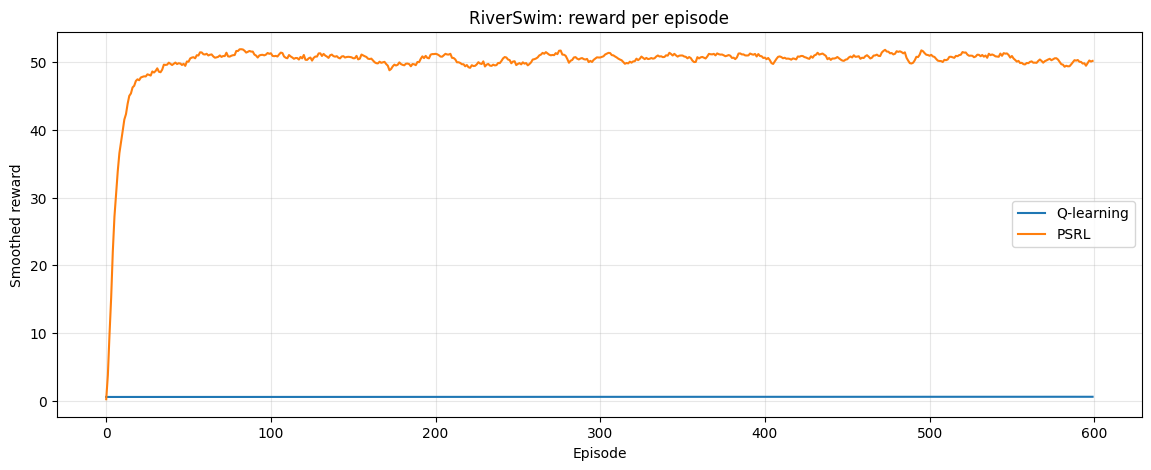

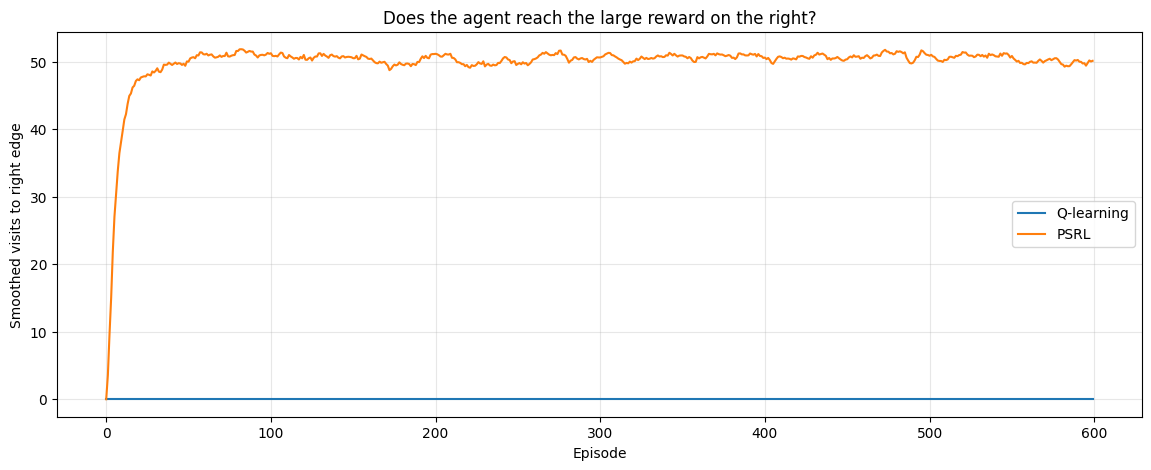

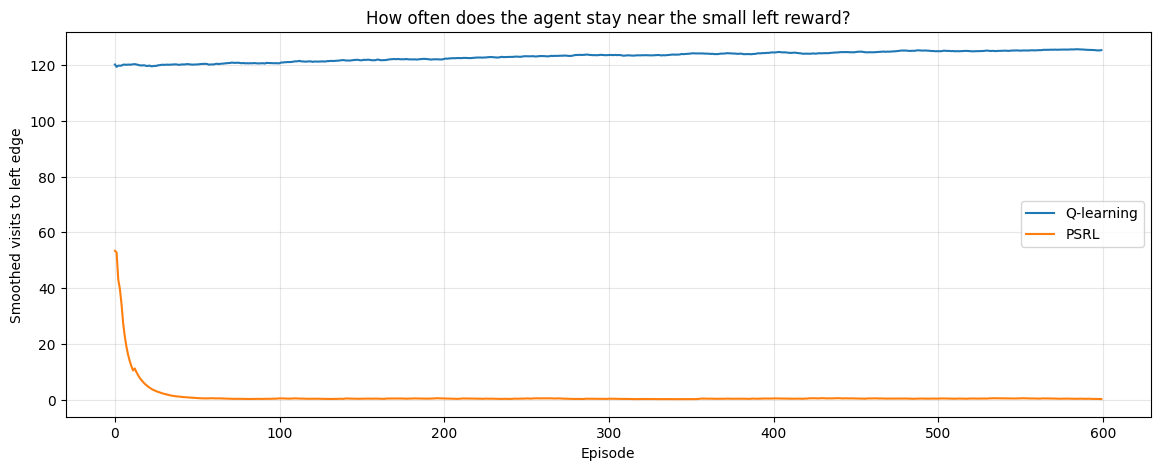

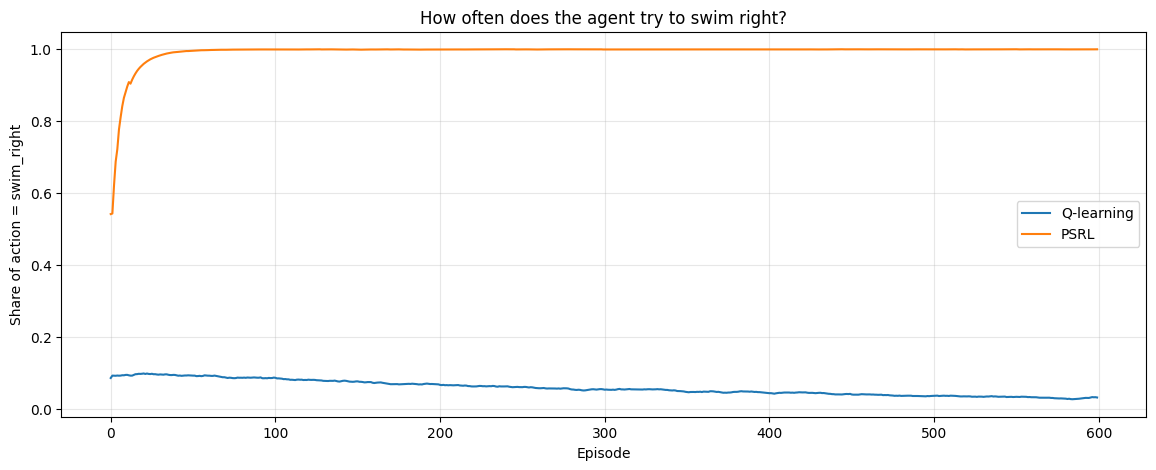

In [ ]:

plot_metric(
    history,
    metric="reward",
    ylabel="Smoothed reward",
    title="RiverSwim: reward per episode",
)

plot_metric(
    history,
    metric="right_visits",
    ylabel="Smoothed visits to right edge",
    title="Does the agent reach the large reward on the right?",
)

plot_metric(
    history,
    metric="left_visits",
    ylabel="Smoothed visits to left edge",
    title="How often does the agent stay near the small left reward?",
)

plot_metric(
    history,
    metric="swim_share",
    ylabel="Share of action = swim_right",
    title="How often does the agent try to swim right?",
)


In [ ]:

summary = (
    history[history["episode"] >= EPISODES - 100]
    .groupby("algorithm")
    [["reward", "right_visits", "left_visits", "swim_share", "regret"]]
    .mean()
    .sort_values("reward", ascending=False)
)

summary


,reward,right_visits,left_visits,swim_share,regret
algorithm,,,,,
PSRL,50.306650,50.305,0.330,0.999277,0.342164
Q-learning,0.626725,0.000,125.345,0.033359,50.022089



## 9. Кумулятивный regret

Здесь используется realised regret:

```text
regret_episode = optimal_expected_episode_value - realised_episode_reward
```

На отдельных эпизодах он может быть шумным, потому что среда стохастическая. Поэтому полезнее смотреть на усреднение по нескольким trials.


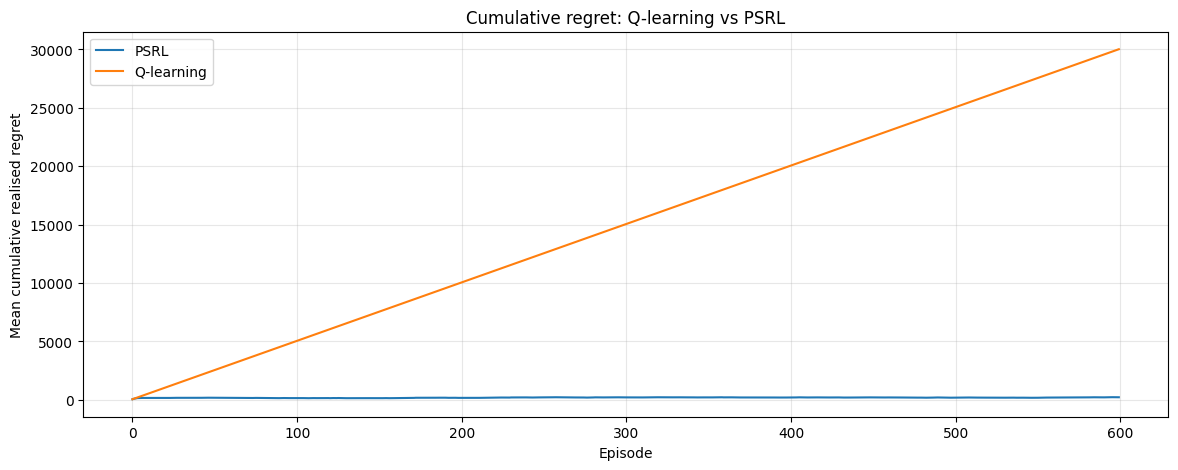

In [ ]:

regret_curve = (
    history.groupby(["algorithm", "trial", "episode"], as_index=False)["regret"]
    .mean()
    .sort_values(["algorithm", "trial", "episode"])
)

regret_curve["cumulative_regret"] = regret_curve.groupby(
    ["algorithm", "trial"]
)["regret"].cumsum()

mean_regret = (
    regret_curve.groupby(["algorithm", "episode"], as_index=False)["cumulative_regret"]
    .mean()
)

plt.figure(figsize=(14, 5))

for algorithm in mean_regret["algorithm"].unique():
    part = mean_regret[mean_regret["algorithm"] == algorithm]
    plt.plot(part["episode"], part["cumulative_regret"], label=algorithm)

plt.xlabel("Episode")
plt.ylabel("Mean cumulative realised regret")
plt.title("Cumulative regret: Q-learning vs PSRL")
plt.grid(alpha=0.3)
plt.legend()
plt.show()



## 10. Визуализация итогового PSRL-агента

Теперь обучим один PSRL-агент и посмотрим:

- его sampled Q-values в начале последнего эпизода;
- его posterior mean reward;
- какие действия он выбирает в начале эпизода по состояниям.


In [ ]:

debug_agent = build_psrl(trial=777)

debug_history = run_agent(
    agent=debug_agent,
    label="PSRL-debug",
    episodes=EPISODES,
    n_intermediate=N_INTERMEDIATE,
    horizon=HORIZON,
    start_state=START_STATE,
    base_seed=777_000,
    optimal_episode_value=OPTIMAL_EPISODE_VALUE,
)

print("Mean reward over last 100 episodes:", debug_history["reward"].tail(100).mean())
print("Mean right visits over last 100 episodes:", debug_history["right_visits"].tail(100).mean())


Mean reward over last 100 episodes: 50.87115
Mean right visits over last 100 episodes: 50.87


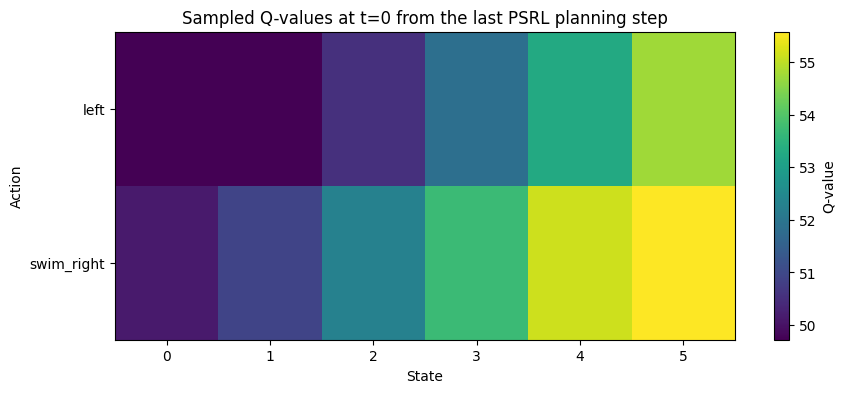

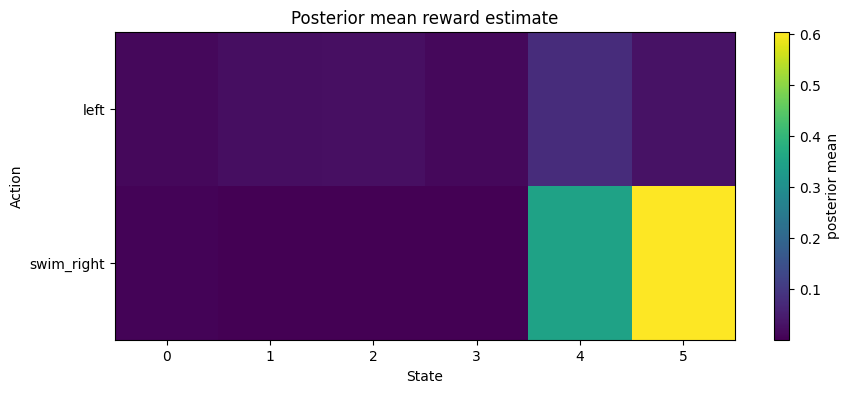

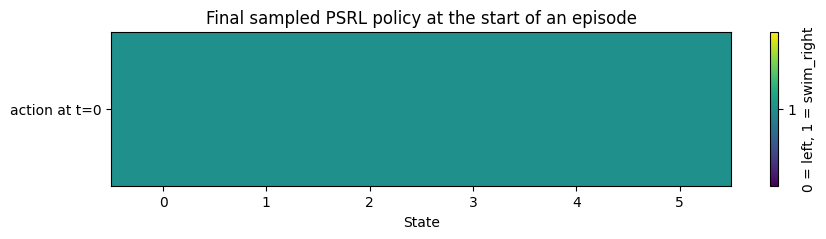

In [ ]:

plt.figure(figsize=(10, 4))
plt.imshow(debug_agent.get_q_matrix().T, aspect="auto")
plt.yticks([0, 1], ["left", "swim_right"])
plt.xticks(np.arange(S), np.arange(S))
plt.xlabel("State")
plt.ylabel("Action")
plt.title("Sampled Q-values at t=0 from the last PSRL planning step")
plt.colorbar(label="Q-value")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(debug_agent.get_reward_mean().T, aspect="auto")
plt.yticks([0, 1], ["left", "swim_right"])
plt.xticks(np.arange(S), np.arange(S))
plt.xlabel("State")
plt.ylabel("Action")
plt.title("Posterior mean reward estimate")
plt.colorbar(label="posterior mean")
plt.show()

plt.figure(figsize=(10, 2))
plt.imshow(debug_agent.policy[0].reshape(1, -1), aspect="auto")
plt.yticks([0], ["action at t=0"])
plt.xticks(np.arange(S), np.arange(S))
plt.xlabel("State")
plt.title("Final sampled PSRL policy at the start of an episode")
plt.colorbar(ticks=[0, 1], label="0 = left, 1 = swim_right")
plt.show()



## 11. Мини-вывод для отчёта

PSRL решает главную проблему RiverSwim: exploration становится не локальным, а эпизодическим и последовательным.

`Q-learning` с epsilon-greedy выбирает случайные действия по одному. Даже если он иногда выбирает `swim_right`, течение часто возвращает его назад, и агент быстро закрепляется около маленькой награды слева.

`PSRL` в начале эпизода сэмплирует целую модель среды. Если в этой модели правый край выглядит перспективно, оптимальная политика будет несколько шагов подряд вести агента вправо. Поэтому агент реально проверяет гипотезу о большой награде справа и быстрее находит хорошую стратегию.

Именно это и является ключевой идеей Posterior Sampling for Reinforcement Learning: агент выбирает политику пропорционально вероятности того, что она оптимальна в текущем posterior по MDP.


In [ ]:
def evaluate_agent_many_seeds(agent_cls, agent_kwargs, seeds, episodes=500, last_n=100):
    results = []

    for seed in seeds:
        agent = agent_cls(**agent_kwargs, seed=seed)

        history = run_agent(
            agent,
            n_intermediate=n_intermediate,
            max_steps=max_steps,
            episodes=episodes,
            seed=1000 + seed,
        )

        results.append({
            "seed": seed,
            "mean_reward_last": history["reward"].tail(last_n).mean(),
            "mean_right_visits_last": history["right_visits"].tail(last_n).mean(),
            "mean_swim_share_last": history["swim_share"].tail(last_n).mean(),
            "total_reward": history["reward"].sum(),
        })

    return pd.DataFrame(results)


seeds = list(range(20))

q_results = evaluate_agent_many_seeds(
    QLearningAgent,
    {
        "n_states": S,
        "n_actions": A,
        "lr": 0.2,
        "gamma": 0.95,
        "epsilon": 0.2,
    },
    seeds,
    episodes=500,
    last_n=100,
)

psrl_results = evaluate_agent_many_seeds(
    PSRLAgent,
    {
        "n_states": S,
        "n_actions": A,
        "horizon": max_steps,
        "gamma": 1.0,
        "prior_transition": 0.2,
        "structured_prior": True,
    },
    seeds,
    episodes=500,
    last_n=100,
)

summary = pd.DataFrame({
    "Q-learning mean": q_results.mean(numeric_only=True),
    "Q-learning std": q_results.std(numeric_only=True),
    "PSRL mean": psrl_results.mean(numeric_only=True),
    "PSRL std": psrl_results.std(numeric_only=True),
})

summary

TypeError: QLearningAgent.__init__() got an unexpected keyword argument 'lr'